# Comparacion temporal CEN: demanda neta, demanda neta + ERV, balance y retiros por barra

Este notebook compara dos magnitudes horarias del archivo CEN `wp2_elec_input_net_demand_raw.csv`:

- `demanda_neta_mwh`
- `demanda_mas_erv_mwh = demanda_neta_mwh + gen_erv_mwh`

Adicionalmente, incorpora en la comparacion anual:

- `wp2_elec_input_sector_shares_raw.csv`, con valores anuales por region y sector en GWh, agregados a escala nacional y convertidos a TWh para visualizacion.
- `demanda_comunal_horaria.csv`, con retiros CEN preprocesados a nivel comunal horario en MWh, agregados a escala nacional anual y convertidos a TWh para visualizacion.

El notebook tambien diagnostica comunas ausentes por a?o y agrega una comparacion por horas coincidentes entre `Demanda neta + Gen ERV` y `Retiros por barra CEN`. En esa vista, BNE se mantiene como referencia anual completa porque no tiene resolucion horaria.

Los calculos internos principales se conservan en MWh para trazabilidad; las tablas y graficos anuales usan TWh porque las magnitudes nacionales son altas.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

print("[1/15] Librerias cargadas y opciones configuradas.")

[1/15] Librerias cargadas y opciones configuradas.


In [2]:
print("[2/15] Buscando archivo de entrada...")

csv_name = "wp2_elec_input_net_demand_raw.csv"
candidate_paths = [
    Path("../data") / csv_name,
    Path("prototipo_2/data") / csv_name,
    Path.cwd() / "../data" / csv_name,
    Path.cwd() / "prototipo_2/data" / csv_name,
    Path.cwd().parent / "data" / csv_name,
]

data_path = next((path.resolve() for path in candidate_paths if path.exists()), None)
if data_path is None:
    searched = "\n".join(str(path) for path in candidate_paths)
    raise FileNotFoundError(f"No se encontro {csv_name}. Rutas revisadas:\n{searched}")

print(f"Archivo encontrado: {data_path}")

[2/15] Buscando archivo de entrada...
Archivo encontrado: C:\Users\Raimundo Claren\Documents\MERLIN_EDM\prototipo_2\data\wp2_elec_input_net_demand_raw.csv


In [3]:
print("[3/15] Cargando datos horarios y validando columnas...")

required_columns = {"fecha_hora", "demanda_neta_mwh", "gen_erv_mwh"}
df = pd.read_csv(data_path)

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

df = df.copy()
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"], errors="coerce")
for column in ["demanda_neta_mwh", "gen_erv_mwh"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_rows = df[list(required_columns)].isna().any(axis=1).sum()
if invalid_rows:
    raise ValueError(f"Existen {invalid_rows:,} filas con nulos en columnas requeridas.")

df = df.sort_values("fecha_hora").reset_index(drop=True)
df["anio"] = df["fecha_hora"].dt.year

diagnostico_basico = pd.DataFrame(
    {
        "metrica": [
            "registros",
            "fecha_inicial",
            "fecha_final",
            "duplicados_fecha_hora",
            "nulos_fecha_hora",
            "nulos_demanda_neta_mwh",
            "nulos_gen_erv_mwh",
        ],
        "valor": [
            len(df),
            df["fecha_hora"].min(),
            df["fecha_hora"].max(),
            df["fecha_hora"].duplicated().sum(),
            df["fecha_hora"].isna().sum(),
            df["demanda_neta_mwh"].isna().sum(),
            df["gen_erv_mwh"].isna().sum(),
        ],
    }
)

display(diagnostico_basico)
display(df.head())

[3/15] Cargando datos horarios y validando columnas...


,metrica,valor
0,registros,82104
1,fecha_inicial,2017-01-01 00:00:00
2,fecha_final,2026-05-18 23:00:00
3,duplicados_fecha_hora,0
4,nulos_fecha_hora,0
5,nulos_demanda_neta_mwh,0
6,nulos_gen_erv_mwh,0


,gen_bruta_mwh,gen_erv_mwh,cons_propio_mwh,cons_propio_porc,demanda_neta_mwh,fecha_hora,hora,_download_startDate,_download_endDate_inclusive,_api_endDate_sent,_download_page,anio
0,"9,024.61","3,882.37",343.55,6.68,"4,798.69",2017-01-01 00:00:00,1,2017-01-01,2017-01-31,2017-02-01,1,2017
1,"8,953.63","3,737.02",336.76,6.46,"4,879.85",2017-01-01 01:00:00,2,2017-01-01,2017-01-31,2017-02-01,1,2017
2,"8,766.45","3,560.18",333.53,6.41,"4,872.74",2017-01-01 02:00:00,3,2017-01-01,2017-01-31,2017-02-01,1,2017
3,"8,503.31","3,444.00",328.54,6.49,"4,730.77",2017-01-01 03:00:00,4,2017-01-01,2017-01-31,2017-02-01,1,2017
4,"8,347.02","3,301.18",332.70,6.59,"4,713.13",2017-01-01 04:00:00,5,2017-01-01,2017-01-31,2017-02-01,1,2017


In [4]:
print("[4/15] Evaluando completitud temporal anual...")

def expected_hours_for_year(year: int) -> int:
    year_start = pd.Timestamp(year=year, month=1, day=1, hour=0)
    return 8784 if year_start.is_leap_year else 8760


def classify_year(row: pd.Series) -> str:
    year = int(row.name)
    year_start = pd.Timestamp(year=year, month=1, day=1, hour=0)
    year_end = pd.Timestamp(year=year, month=12, day=31, hour=23)

    if row["primera_fecha"] > year_start or row["ultima_fecha"] < year_end:
        return "Parcial"
    if row["timestamps_unicos"] < row["horas_esperadas_anio"] or row["duplicados"] > 0:
        return "Incompleto"
    return "Completo"


completitud_anual = df.groupby("anio").agg(
    registros=("fecha_hora", "size"),
    timestamps_unicos=("fecha_hora", "nunique"),
    primera_fecha=("fecha_hora", "min"),
    ultima_fecha=("fecha_hora", "max"),
).sort_index()
completitud_anual["duplicados"] = completitud_anual["registros"] - completitud_anual["timestamps_unicos"]
completitud_anual["horas_esperadas_anio"] = [expected_hours_for_year(year) for year in completitud_anual.index]
completitud_anual["horas_faltantes_calendario"] = (
    completitud_anual["horas_esperadas_anio"] - completitud_anual["timestamps_unicos"]
).clip(lower=0)
completitud_anual["estado"] = completitud_anual.apply(classify_year, axis=1)

display(completitud_anual.reset_index().rename(columns={"anio": "Anio"}))

anios_no_completos = completitud_anual[completitud_anual["estado"] != "Completo"]
if anios_no_completos.empty:
    print("Todos los anios del archivo estan completos a resolucion horaria.")
else:
    print("Anios parciales o incompletos detectados; interpretar sus totales anuales con cautela:")
    display(anios_no_completos.reset_index().rename(columns={"anio": "Anio"}))

[4/15] Evaluando completitud temporal anual...


,Anio,registros,timestamps_unicos,primera_fecha,ultima_fecha,duplicados,horas_esperadas_anio,horas_faltantes_calendario,estado
0,2017,8760,8760,2017-01-01,2017-12-31 23:00:00,0,8760,0,Completo
1,2018,8760,8760,2018-01-01,2018-12-31 23:00:00,0,8760,0,Completo
2,2019,8760,8760,2019-01-01,2019-12-31 23:00:00,0,8760,0,Completo
3,2020,8784,8784,2020-01-01,2020-12-31 23:00:00,0,8784,0,Completo
4,2021,8760,8760,2021-01-01,2021-12-31 23:00:00,0,8760,0,Completo
5,2022,8760,8760,2022-01-01,2022-12-31 23:00:00,0,8760,0,Completo
6,2023,8664,8664,2023-01-01,2023-12-31 23:00:00,0,8760,96,Incompleto
7,2024,8784,8784,2024-01-01,2024-12-31 23:00:00,0,8784,0,Completo
8,2025,8760,8760,2025-01-01,2025-12-31 23:00:00,0,8760,0,Completo
9,2026,3312,3312,2026-01-01,2026-05-18 23:00:00,0,8760,5448,Parcial


Anios parciales o incompletos detectados; interpretar sus totales anuales con cautela:


,Anio,registros,timestamps_unicos,primera_fecha,ultima_fecha,duplicados,horas_esperadas_anio,horas_faltantes_calendario,estado
0,2023,8664,8664,2023-01-01,2023-12-31 23:00:00,0,8760,96,Incompleto
1,2026,3312,3312,2026-01-01,2026-05-18 23:00:00,0,8760,5448,Parcial


In [5]:
print("[5/15] Calculando demanda_neta_mwh + gen_erv_mwh...")

df["demanda_mas_erv_mwh"] = df["demanda_neta_mwh"] + df["gen_erv_mwh"]

calculo_ok = np.allclose(
    df["demanda_mas_erv_mwh"],
    df["demanda_neta_mwh"] + df["gen_erv_mwh"],
    equal_nan=False,
)
if not calculo_ok:
    raise AssertionError("La variable demanda_mas_erv_mwh no coincide con la suma esperada.")

display(df[["fecha_hora", "demanda_neta_mwh", "gen_erv_mwh", "demanda_mas_erv_mwh"]].head())
print("Calculo validado correctamente.")

[5/15] Calculando demanda_neta_mwh + gen_erv_mwh...


,fecha_hora,demanda_neta_mwh,gen_erv_mwh,demanda_mas_erv_mwh
0,2017-01-01 00:00:00,"4,798.69","3,882.37","8,681.06"
1,2017-01-01 01:00:00,"4,879.85","3,737.02","8,616.87"
2,2017-01-01 02:00:00,"4,872.74","3,560.18","8,432.92"
3,2017-01-01 03:00:00,"4,730.77","3,444.00","8,174.77"
4,2017-01-01 04:00:00,"4,713.13","3,301.18","8,014.31"


Calculo validado correctamente.


[6/15] Generando curvas temporales...


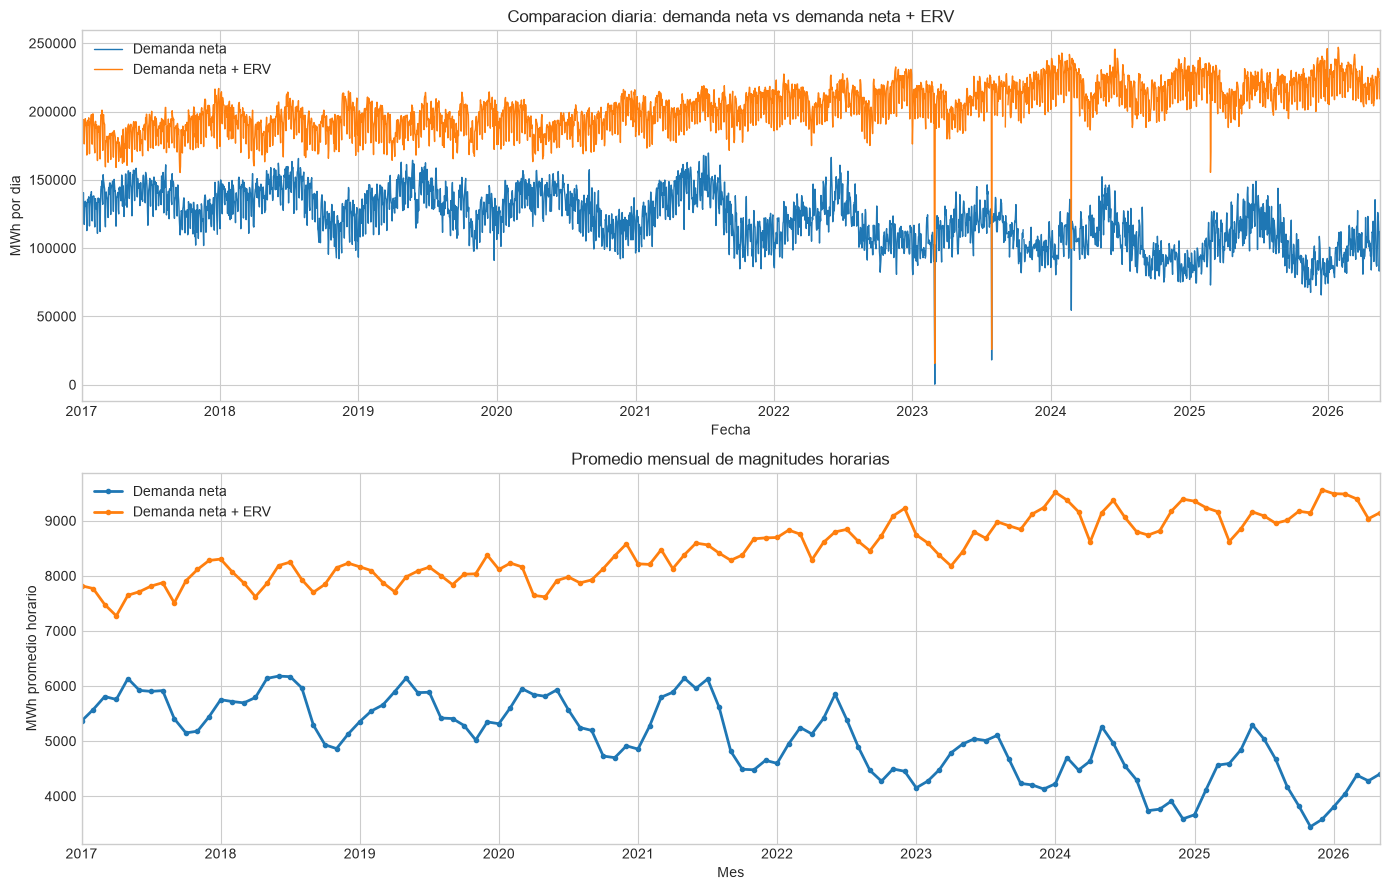

In [6]:
print("[6/15] Generando curvas temporales...")

serie = df.set_index("fecha_hora")[["demanda_neta_mwh", "demanda_mas_erv_mwh"]]

# Vista diaria: suma la energia horaria de cada dia para reducir ruido visual.
serie_diaria = serie.resample("D").sum(min_count=1)

# Vista mensual: promedio de magnitudes horarias dentro de cada mes.
serie_mensual_promedio = serie.resample("MS").mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

serie_diaria.plot(ax=axes[0], linewidth=1.0)
axes[0].set_title("Comparacion diaria: demanda neta vs demanda neta + ERV")
axes[0].set_ylabel("MWh por dia")
axes[0].set_xlabel("Fecha")
axes[0].legend(["Demanda neta", "Demanda neta + ERV"])

serie_mensual_promedio.plot(ax=axes[1], linewidth=2.0, marker="o", markersize=3)
axes[1].set_title("Promedio mensual de magnitudes horarias")
axes[1].set_ylabel("MWh promedio horario")
axes[1].set_xlabel("Mes")
axes[1].legend(["Demanda neta", "Demanda neta + ERV"])

plt.tight_layout()
plt.show()

In [7]:
print("[7/15] Integrando magnitudes anualmente...")

MWH_POR_TWH = 1_000_000
GWH_POR_TWH = 1_000

integracion_anual = df.groupby("anio", as_index=False).agg(
    demanda_neta_anual_mwh=("demanda_neta_mwh", "sum"),
    gen_erv_anual_mwh=("gen_erv_mwh", "sum"),
    demanda_mas_erv_anual_mwh=("demanda_mas_erv_mwh", "sum"),
)
integracion_anual["diferencia_mwh"] = (
    integracion_anual["demanda_mas_erv_anual_mwh"] - integracion_anual["demanda_neta_anual_mwh"]
)
integracion_anual["diferencia_pct_sobre_demanda_neta"] = (
    integracion_anual["diferencia_mwh"] / integracion_anual["demanda_neta_anual_mwh"] * 100
)

for column in [
    "demanda_neta_anual_mwh",
    "gen_erv_anual_mwh",
    "demanda_mas_erv_anual_mwh",
    "diferencia_mwh",
]:
    integracion_anual[column.replace("_mwh", "_twh")] = integracion_anual[column] / MWH_POR_TWH

reporte_anual = integracion_anual.merge(
    completitud_anual.reset_index()[["anio", "registros", "horas_esperadas_anio", "horas_faltantes_calendario", "estado"]],
    on="anio",
    how="left",
)

reporte_anual_display = reporte_anual[
    [
        "anio",
        "demanda_neta_anual_twh",
        "gen_erv_anual_twh",
        "demanda_mas_erv_anual_twh",
        "diferencia_twh",
        "diferencia_pct_sobre_demanda_neta",
        "registros",
        "horas_esperadas_anio",
        "horas_faltantes_calendario",
        "estado",
    ]
].rename(
    columns={
        "anio": "Anio",
        "demanda_neta_anual_twh": "Demanda neta anual TWh",
        "gen_erv_anual_twh": "Generacion ERV anual TWh",
        "demanda_mas_erv_anual_twh": "Demanda neta + ERV anual TWh",
        "diferencia_twh": "Diferencia TWh",
        "diferencia_pct_sobre_demanda_neta": "Diferencia pct sobre demanda neta",
        "registros": "Registros",
        "horas_esperadas_anio": "Horas esperadas anio",
        "horas_faltantes_calendario": "Horas faltantes calendario",
        "estado": "Estado",
    }
)

display(reporte_anual_display)


[7/15] Integrando magnitudes anualmente...


,Anio,Demanda neta anual TWh,Generacion ERV anual TWh,Demanda neta + ERV anual TWh,Diferencia TWh,Diferencia pct sobre demanda neta,Registros,Horas esperadas anio,Horas faltantes calendario,Estado
0,2017,49.32,18.73,68.04,18.73,37.97,8760,8760,0,Completo
1,2018,49.36,20.73,70.10,20.73,42.00,8760,8760,0,Completo
2,2019,48.79,21.55,70.34,21.55,44.17,8760,8760,0,Completo
3,2020,47.42,23.24,70.66,23.24,49.00,8784,8784,0,Completo
4,2021,46.78,26.96,73.74,26.96,57.62,8760,8760,0,Completo
5,2022,43.17,33.44,76.61,33.44,77.45,8760,8760,0,Completo
6,2023,39.75,35.99,75.74,35.99,90.55,8664,8760,96,Incompleto
7,2024,38.12,41.79,79.91,41.79,109.62,8784,8784,0,Completo
8,2025,37.81,41.99,79.80,41.99,111.04,8760,8760,0,Completo
9,2026,13.79,17.09,30.88,17.09,123.93,3312,8760,5448,Parcial


## Balance nacional anual agregado por region y sector

Esta seccion usa `wp2_elec_input_sector_shares_raw.csv` solo para la comparacion anual. Los valores originales estan en GWh, por lo que la agregacion nacional se convierte a MWh antes de compararse con `demanda_neta_anual_mwh` y `demanda_mas_erv_anual_mwh`.

In [8]:
print("[8/15] Cargando balance regional-sectorial y agregando a escala nacional...")

balance_csv_name = "wp2_elec_input_sector_shares_raw.csv"
balance_candidate_paths = [
    Path("../data") / balance_csv_name,
    Path("prototipo_2/data") / balance_csv_name,
    Path.cwd() / "../data" / balance_csv_name,
    Path.cwd() / "prototipo_2/data" / balance_csv_name,
    Path.cwd().parent / "data" / balance_csv_name,
]

balance_path = next((path.resolve() for path in balance_candidate_paths if path.exists()), None)
if balance_path is None:
    searched = "\n".join(str(path) for path in balance_candidate_paths)
    raise FileNotFoundError(f"No se encontro {balance_csv_name}. Rutas revisadas:\n{searched}")

print(f"Archivo de balance encontrado: {balance_path}")

balance_raw = pd.read_csv(balance_path)
if balance_raw.shape[1] < 4:
    raise ValueError("El balance regional-sectorial debe tener al menos cuatro columnas: anio, region, sector y valor.")

# Normalizacion por posicion para evitar problemas de codificacion con nombres como 'a?o' y 'regi?n'.
df_balance = balance_raw.iloc[:, :4].copy()
df_balance.columns = ["anio", "region", "sector", "valor_gwh"]

df_balance["anio"] = pd.to_numeric(df_balance["anio"], errors="coerce").astype("Int64")
df_balance["region"] = df_balance["region"].astype(str).str.strip()
df_balance["sector"] = df_balance["sector"].astype(str).str.strip()
df_balance["valor_gwh"] = pd.to_numeric(df_balance["valor_gwh"], errors="coerce")

balance_nulls = df_balance[["anio", "region", "sector", "valor_gwh"]].isna().sum()
if balance_nulls.any():
    raise ValueError(f"Existen nulos o valores invalidos en el balance normalizado:\n{balance_nulls}")

df_balance["anio"] = df_balance["anio"].astype(int)
df_balance["valor_twh"] = df_balance["valor_gwh"] / GWH_POR_TWH

balance_nacional_anual = df_balance.groupby("anio", as_index=False).agg(
    balance_nacional_anual_gwh=("valor_gwh", "sum"),
    regiones_incluidas=("region", "nunique"),
    sectores_incluidos=("sector", "nunique"),
    registros_balance=("valor_gwh", "size"),
)
balance_nacional_anual["balance_nacional_anual_mwh"] = balance_nacional_anual["balance_nacional_anual_gwh"] * 1000
balance_nacional_anual["balance_nacional_anual_twh"] = balance_nacional_anual["balance_nacional_anual_gwh"] / GWH_POR_TWH

comparacion_anual = reporte_anual.merge(balance_nacional_anual, on="anio", how="left")
comparacion_anual["balance_vs_demanda_neta_mwh"] = (
    comparacion_anual["balance_nacional_anual_mwh"] - comparacion_anual["demanda_neta_anual_mwh"]
)
comparacion_anual["balance_vs_demanda_neta_twh"] = comparacion_anual["balance_vs_demanda_neta_mwh"] / MWH_POR_TWH
comparacion_anual["balance_vs_demanda_neta_pct"] = (
    comparacion_anual["balance_vs_demanda_neta_mwh"] / comparacion_anual["demanda_neta_anual_mwh"] * 100
)
comparacion_anual["balance_vs_demanda_mas_erv_mwh"] = (
    comparacion_anual["balance_nacional_anual_mwh"] - comparacion_anual["demanda_mas_erv_anual_mwh"]
)
comparacion_anual["balance_vs_demanda_mas_erv_twh"] = comparacion_anual["balance_vs_demanda_mas_erv_mwh"] / MWH_POR_TWH
comparacion_anual["balance_vs_demanda_mas_erv_pct"] = (
    comparacion_anual["balance_vs_demanda_mas_erv_mwh"] / comparacion_anual["demanda_mas_erv_anual_mwh"] * 100
)

anios_balance = sorted(balance_nacional_anual["anio"].tolist())
anios_cen = sorted(reporte_anual["anio"].tolist())
anios_comunes_balance_cen = sorted(set(anios_balance).intersection(anios_cen))
anios_cen_sin_balance = sorted(set(anios_cen).difference(anios_balance))
anios_balance_sin_cen = sorted(set(anios_balance).difference(anios_cen))

print(f"Anios disponibles en balance: {anios_balance}")
print(f"Anios comunes CEN/balance: {anios_comunes_balance_cen}")
print(f"Anios CEN sin balance: {anios_cen_sin_balance}")
print(f"Anios balance sin CEN: {anios_balance_sin_cen}")
print(f"Regiones incluidas: {df_balance['region'].nunique()}")
print(f"Sectores incluidos: {sorted(df_balance['sector'].unique())}")

balance_extremos = df_balance.sort_values("valor_gwh", ascending=False).head(10)
print("Mayores registros individuales del balance, en GWh y TWh:")
display(balance_extremos)

comparacion_anual_display = comparacion_anual[
    [
        "anio",
        "demanda_neta_anual_twh",
        "gen_erv_anual_twh",
        "demanda_mas_erv_anual_twh",
        "balance_nacional_anual_twh",
        "balance_vs_demanda_neta_twh",
        "balance_vs_demanda_neta_pct",
        "balance_vs_demanda_mas_erv_twh",
        "balance_vs_demanda_mas_erv_pct",
        "estado",
        "regiones_incluidas",
        "sectores_incluidos",
        "registros_balance",
    ]
].rename(
    columns={
        "anio": "Anio",
        "demanda_neta_anual_twh": "Demanda neta anual TWh",
        "gen_erv_anual_twh": "Generacion ERV anual TWh",
        "demanda_mas_erv_anual_twh": "Demanda neta + ERV anual TWh",
        "balance_nacional_anual_twh": "Balance nacional anual TWh",
        "balance_vs_demanda_neta_twh": "Balance - demanda neta TWh",
        "balance_vs_demanda_neta_pct": "Balance - demanda neta pct",
        "balance_vs_demanda_mas_erv_twh": "Balance - demanda neta + ERV TWh",
        "balance_vs_demanda_mas_erv_pct": "Balance - demanda neta + ERV pct",
        "estado": "Estado CEN",
        "regiones_incluidas": "Regiones balance",
        "sectores_incluidos": "Sectores balance",
        "registros_balance": "Registros balance",
    }
)

display(comparacion_anual_display)


[8/15] Cargando balance regional-sectorial y agregando a escala nacional...
Archivo de balance encontrado: C:\Users\Raimundo Claren\Documents\MERLIN_EDM\prototipo_2\data\wp2_elec_input_sector_shares_raw.csv
Anios disponibles en balance: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Anios comunes CEN/balance: [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Anios CEN sin balance: [2017, 2025, 2026]
Anios balance sin CEN: []
Regiones incluidas: 16
Sectores incluidos: ['Comercial', 'Industrial', 'Público', 'Residencial', 'Transporte']
Mayores registros individuales del balance, en GWh y TWh:


,anio,region,sector,valor_gwh,valor_twh
306,2022,AN,Industrial,"17,109.39",17.11
156,2020,AN,Industrial,"16,468.68",16.47
385,2023,AN,Industrial,"16,453.78",16.45
231,2021,AN,Industrial,"16,282.15",16.28
80,2019,AN,Industrial,"14,981.81",14.98
465,2024,AN,Industrial,"13,948.56",13.95
6,2018,AN,Industrial,"13,631.63",13.63
445,2023,RM,Industrial,"12,219.40",12.22
525,2024,RM,Industrial,"10,040.52",10.04
62,2018,RM,Industrial,"9,360.22",9.36


,Anio,Demanda neta anual TWh,Generacion ERV anual TWh,Demanda neta + ERV anual TWh,Balance nacional anual TWh,Balance - demanda neta TWh,Balance - demanda neta pct,Balance - demanda neta + ERV TWh,Balance - demanda neta + ERV pct,Estado CEN,Regiones balance,Sectores balance,Registros balance
0,2017,49.32,18.73,68.04,NaN,NaN,NaN,NaN,NaN,Completo,NaN,NaN,NaN
1,2018,49.36,20.73,70.10,73.13,23.76,48.14,3.03,4.32,Completo,16.00,5.00,75.00
2,2019,48.79,21.55,70.34,74.21,25.42,52.11,3.87,5.51,Completo,16.00,5.00,75.00
3,2020,47.42,23.24,70.66,74.36,26.94,56.81,3.70,5.24,Completo,16.00,5.00,76.00
4,2021,46.78,26.96,73.74,76.33,29.55,63.17,2.59,3.52,Completo,16.00,5.00,75.00
5,2022,43.17,33.44,76.61,80.74,37.57,87.04,4.14,5.40,Completo,16.00,5.00,78.00
6,2023,39.75,35.99,75.74,82.24,42.49,106.90,6.50,8.58,Incompleto,16.00,5.00,80.00
7,2024,38.12,41.79,79.91,82.14,44.02,115.47,2.23,2.79,Completo,16.00,5.00,80.00
8,2025,37.81,41.99,79.80,NaN,NaN,NaN,NaN,NaN,Completo,NaN,NaN,NaN
9,2026,13.79,17.09,30.88,NaN,NaN,NaN,NaN,NaN,Parcial,NaN,NaN,NaN


## Demanda comunal anual agregada a escala nacional

Esta seccion incorpora `demanda_comunal_horaria.csv`, que contiene retiros CEN preprocesados a nivel comunal horario. La agregacion nacional anual suma `demanda_mwh` sobre todas las comunas y conserva los valores negativos como parte del total observado, reportandolos como diagnostico metodologico.

In [9]:
print("[9/15] Cargando demanda comunal horaria y agregando a escala nacional...")

comunal_csv_name = "demanda_comunal_horaria.csv"
comunal_candidate_paths = [
    Path("../data") / comunal_csv_name,
    Path("prototipo_2/data") / comunal_csv_name,
    Path.cwd() / "../data" / comunal_csv_name,
    Path.cwd() / "prototipo_2/data" / comunal_csv_name,
    Path.cwd().parent / "data" / comunal_csv_name,
]

comunal_path = next((path.resolve() for path in comunal_candidate_paths if path.exists()), None)
if comunal_path is None:
    searched = "\n".join(str(path) for path in comunal_candidate_paths)
    raise FileNotFoundError(f"No se encontro {comunal_csv_name}. Rutas revisadas:\n{searched}")

print(f"Archivo de demanda comunal encontrado: {comunal_path}")

required_comunal_columns = {"valid_time", "comuna", "demanda_mwh"}
df_comunal = pd.read_csv(comunal_path)
missing_comunal_columns = required_comunal_columns.difference(df_comunal.columns)
if missing_comunal_columns:
    raise ValueError(f"Faltan columnas requeridas en demanda comunal: {sorted(missing_comunal_columns)}")

df_comunal = df_comunal[["valid_time", "comuna", "demanda_mwh"]].copy()
df_comunal["valid_time"] = pd.to_datetime(df_comunal["valid_time"], errors="coerce")
df_comunal["comuna"] = df_comunal["comuna"].astype(str).str.strip()
df_comunal["demanda_mwh"] = pd.to_numeric(df_comunal["demanda_mwh"], errors="coerce")

comunal_nulls = df_comunal[["valid_time", "comuna", "demanda_mwh"]].isna().sum()
if comunal_nulls.any():
    raise ValueError(f"Existen nulos o valores invalidos en la demanda comunal:\n{comunal_nulls}")

df_comunal["anio"] = df_comunal["valid_time"].dt.year
df_comunal["demanda_negativa"] = df_comunal["demanda_mwh"] < 0

completitud_comunal = df_comunal.groupby("anio").agg(
    registros_comunal=("valid_time", "size"),
    timestamps_unicos_comunal=("valid_time", "nunique"),
    primera_fecha_comunal=("valid_time", "min"),
    ultima_fecha_comunal=("valid_time", "max"),
    comunas_comunal=("comuna", "nunique"),
    filas_negativas_comunal=("demanda_negativa", "sum"),
).sort_index()
completitud_comunal["horas_esperadas_comunal"] = [
    expected_hours_for_year(year) for year in completitud_comunal.index
]
completitud_comunal["horas_faltantes_comunal"] = (
    completitud_comunal["horas_esperadas_comunal"] - completitud_comunal["timestamps_unicos_comunal"]
).clip(lower=0)


def classify_communal_year(row: pd.Series) -> str:
    year = int(row.name)
    year_start = pd.Timestamp(year=year, month=1, day=1, hour=0)
    year_end = pd.Timestamp(year=year, month=12, day=31, hour=23)

    if row["primera_fecha_comunal"] > year_start or row["ultima_fecha_comunal"] < year_end:
        return "Parcial"
    if row["timestamps_unicos_comunal"] < row["horas_esperadas_comunal"]:
        return "Incompleto"
    return "Completo"


completitud_comunal["estado_comunal"] = completitud_comunal.apply(classify_communal_year, axis=1)

demanda_comunal_anual = df_comunal.groupby("anio", as_index=False).agg(
    demanda_comunal_anual_mwh=("demanda_mwh", "sum"),
)
demanda_comunal_anual["demanda_comunal_anual_twh"] = (
    demanda_comunal_anual["demanda_comunal_anual_mwh"] / MWH_POR_TWH
)

demanda_comunal_anual = demanda_comunal_anual.merge(
    completitud_comunal.reset_index()[
        [
            "anio",
            "estado_comunal",
            "registros_comunal",
            "timestamps_unicos_comunal",
            "horas_esperadas_comunal",
            "horas_faltantes_comunal",
            "primera_fecha_comunal",
            "ultima_fecha_comunal",
            "comunas_comunal",
            "filas_negativas_comunal",
        ]
    ],
    on="anio",
    how="left",
)

comparacion_anual = comparacion_anual.merge(demanda_comunal_anual, on="anio", how="left")
comparacion_anual["comunal_vs_demanda_mas_erv_twh"] = (
    comparacion_anual["demanda_comunal_anual_twh"] - comparacion_anual["demanda_mas_erv_anual_twh"]
)
comparacion_anual["comunal_vs_balance_twh"] = (
    comparacion_anual["demanda_comunal_anual_twh"] - comparacion_anual["balance_nacional_anual_twh"]
)

anios_comunal = sorted(demanda_comunal_anual["anio"].tolist())
anios_comunes_tres_fuentes = sorted(
    set(anios_cen).intersection(anios_balance).intersection(anios_comunal)
)

print(f"Anios disponibles en demanda comunal: {anios_comunal}")
print(f"Anios comunes CEN/balance/comunal: {anios_comunes_tres_fuentes}")
print("Cobertura anual de la demanda comunal:")
display(completitud_comunal.reset_index().rename(columns={"anio": "Anio"}))

print("[11/15] Consolidando comparacion anual extendida con retiros por barra...")

comparacion_anual_extendida_display = comparacion_anual[
    [
        "anio",
        "demanda_mas_erv_anual_twh",
        "balance_nacional_anual_twh",
        "demanda_comunal_anual_twh",
        "comunal_vs_demanda_mas_erv_twh",
        "comunal_vs_balance_twh",
        "estado",
        "estado_comunal",
        "horas_faltantes_comunal",
        "comunas_comunal",
        "filas_negativas_comunal",
    ]
].rename(
    columns={
        "anio": "Anio",
        "demanda_mas_erv_anual_twh": "Demanda neta + ERV CEN TWh",
        "balance_nacional_anual_twh": "Balance nacional anual TWh",
        "demanda_comunal_anual_twh": "Demanda comunal nacional TWh",
        "comunal_vs_demanda_mas_erv_twh": "Comunal - demanda neta + ERV TWh",
        "comunal_vs_balance_twh": "Comunal - balance TWh",
        "estado": "Estado CEN",
        "estado_comunal": "Estado comunal",
        "horas_faltantes_comunal": "Horas faltantes comunal",
        "comunas_comunal": "Comunas comunal",
        "filas_negativas_comunal": "Filas negativas comunal",
    }
)

display(comparacion_anual_extendida_display)


[9/15] Cargando demanda comunal horaria y agregando a escala nacional...
Archivo de demanda comunal encontrado: C:\Users\Raimundo Claren\Documents\MERLIN_EDM\prototipo_2\data\demanda_comunal_horaria.csv
Anios disponibles en demanda comunal: [2018, 2019, 2020, 2021, 2022, 2023]
Anios comunes CEN/balance/comunal: [2018, 2019, 2020, 2021, 2022, 2023]
Cobertura anual de la demanda comunal:


,Anio,registros_comunal,timestamps_unicos_comunal,primera_fecha_comunal,ultima_fecha_comunal,comunas_comunal,filas_negativas_comunal,horas_esperadas_comunal,horas_faltantes_comunal,estado_comunal
0,2018,720863,3671,2018-08-01,2018-12-31 23:00:00,199,1312,8760,5089,Parcial
1,2019,1706140,8760,2019-01-01,2019-12-31 23:00:00,196,2812,8760,0,Completo
2,2020,1844850,8784,2020-01-01,2020-12-31 23:00:00,210,445,8784,0,Completo
3,2021,1847155,8760,2021-01-01,2021-12-31 23:00:00,211,180,8760,0,Completo
4,2022,1411682,8040,2022-01-01,2022-12-31 23:00:00,211,1110,8760,720,Incompleto
5,2023,1767287,8760,2023-01-01,2023-12-31 23:00:00,210,2662,8760,0,Completo


[11/15] Consolidando comparacion anual extendida con retiros por barra...


,Anio,Demanda neta + ERV CEN TWh,Balance nacional anual TWh,Demanda comunal nacional TWh,Comunal - demanda neta + ERV TWh,Comunal - balance TWh,Estado CEN,Estado comunal,Horas faltantes comunal,Comunas comunal,Filas negativas comunal
0,2017,68.04,NaN,NaN,NaN,NaN,Completo,NaN,NaN,NaN,NaN
1,2018,70.10,73.13,15.49,-54.60,-57.63,Completo,Parcial,"5,089.00",199.00,"1,312.00"
2,2019,70.34,74.21,34.36,-35.98,-39.85,Completo,Completo,0.00,196.00,"2,812.00"
3,2020,70.66,74.36,70.52,-0.15,-3.85,Completo,Completo,0.00,210.00,445.00
4,2021,73.74,76.33,73.80,0.06,-2.53,Completo,Completo,0.00,211.00,180.00
5,2022,76.61,80.74,44.17,-32.44,-36.58,Completo,Incompleto,720.00,211.00,"1,110.00"
6,2023,75.74,82.24,64.97,-10.77,-17.27,Incompleto,Completo,0.00,210.00,"2,662.00"
7,2024,79.91,82.14,NaN,NaN,NaN,Completo,NaN,NaN,NaN,NaN
8,2025,79.80,NaN,NaN,NaN,NaN,Completo,NaN,NaN,NaN,NaN
9,2026,30.88,NaN,NaN,NaN,NaN,Parcial,NaN,NaN,NaN,NaN


## Diagnostico de comunas ausentes por a?o

Esta seccion identifica comunas que no estan presentes en todos los a?os observados de `demanda_comunal_horaria.csv`. El diagnostico se realiza por presencia anual de la comuna; no evalua completitud horaria comuna-a-comuna.

In [10]:
print("[10/15] Diagnosticando presencia anual de comunas en retiros por barra...")

anios_observados_comunal = sorted(df_comunal["anio"].dropna().astype(int).unique().tolist())
comunas_por_anio = (
    df_comunal.groupby("anio")["comuna"]
    .nunique()
    .rename("comunas_presentes")
    .reset_index()
)

presencia_comuna_anio = (
    df_comunal.groupby(["comuna", "anio"])
    .agg(
        registros=("valid_time", "size"),
        primera_fecha=("valid_time", "min"),
        ultima_fecha=("valid_time", "max"),
    )
    .reset_index()
)

resumen_presencia_comunas = []
for comuna, grupo in presencia_comuna_anio.groupby("comuna"):
    anios_presentes = sorted(grupo["anio"].astype(int).tolist())
    anios_ausentes = [anio for anio in anios_observados_comunal if anio not in anios_presentes]
    if anios_ausentes:
        resumen_presencia_comunas.append(
            {
                "comuna": comuna,
                "primer_anio_observado": min(anios_presentes),
                "ultimo_anio_observado": max(anios_presentes),
                "anios_presentes": ", ".join(map(str, anios_presentes)),
                "anios_ausentes": ", ".join(map(str, anios_ausentes)),
                "n_anios_presentes": len(anios_presentes),
                "n_anios_ausentes": len(anios_ausentes),
            }
        )

diagnostico_comunas_ausentes = pd.DataFrame(resumen_presencia_comunas)
if not diagnostico_comunas_ausentes.empty:
    diagnostico_comunas_ausentes = diagnostico_comunas_ausentes.sort_values(
        ["n_anios_ausentes", "comuna"], ascending=[False, True]
    )

print("Conteo anual de comunas presentes:")
display(comunas_por_anio.rename(columns={"anio": "Anio", "comunas_presentes": "Comunas presentes"}))

print(f"Comunas ausentes en al menos un anio observado: {len(diagnostico_comunas_ausentes)}")
if diagnostico_comunas_ausentes.empty:
    print("Todas las comunas observadas aparecen en todos los anios disponibles de la serie comunal.")
else:
    display(
        diagnostico_comunas_ausentes.rename(
            columns={
                "comuna": "Comuna",
                "primer_anio_observado": "Primer anio observado",
                "ultimo_anio_observado": "Ultimo anio observado",
                "anios_presentes": "Anios presentes",
                "anios_ausentes": "Anios ausentes",
                "n_anios_presentes": "N anios presentes",
                "n_anios_ausentes": "N anios ausentes",
            }
        )
    )


[10/15] Diagnosticando presencia anual de comunas en retiros por barra...
Conteo anual de comunas presentes:


,Anio,Comunas presentes
0,2018,199
1,2019,196
2,2020,210
3,2021,211
4,2022,211
5,2023,210


Comunas ausentes en al menos un anio observado: 19


,Comuna,Primer anio observado,Ultimo anio observado,Anios presentes,Anios ausentes,N anios presentes,N anios ausentes
4,La Higuera,2023,2023,2023,"2018, 2019, 2020, 2021, 2022",1,5
16,San Ignacio,2023,2023,2023,"2018, 2019, 2020, 2021, 2022",1,5
7,Llaillay,2020,2022,"2020, 2021, 2022","2018, 2019, 2023",3,3
11,Puerto Octay,2021,2023,"2021, 2022, 2023","2018, 2019, 2020",3,3
0,Alto Biobío,2020,2023,"2020, 2021, 2022, 2023","2018, 2019",4,2
1,Canela,2020,2023,"2020, 2021, 2022, 2023","2018, 2019",4,2
5,La Reina,2020,2023,"2020, 2021, 2022, 2023","2018, 2019",4,2
8,Lo Espejo,2020,2023,"2020, 2021, 2022, 2023","2018, 2019",4,2
9,Padre Hurtado,2020,2023,"2020, 2021, 2022, 2023","2018, 2019",4,2
10,Pica,2020,2023,"2020, 2021, 2022, 2023","2018, 2019",4,2


## Comparacion anual por horas coincidentes CEN/retiros

Esta seccion extiende la comparacion a a?os parciales o incompletos usando solo timestamps presentes simultaneamente en `Demanda neta + Gen ERV` y `Retiros por barra CEN`. El BNE se conserva como referencia anual completa y no se prorratea, porque no tiene resolucion horaria.

In [11]:
print("[12/15] Calculando comparacion anual por horas coincidentes CEN/retiros...")

cen_horario_comparacion = df[["fecha_hora", "anio", "demanda_neta_mwh", "gen_erv_mwh", "demanda_mas_erv_mwh"]].copy()
retiros_horario_nacional = df_comunal.groupby("valid_time", as_index=False).agg(
    retiros_barra_mwh=("demanda_mwh", "sum"),
    comunas_con_registro=("comuna", "nunique"),
    filas_retiros=("demanda_mwh", "size"),
    filas_negativas_retiros=("demanda_negativa", "sum"),
)

comparacion_horas_comunes = cen_horario_comparacion.merge(
    retiros_horario_nacional,
    left_on="fecha_hora",
    right_on="valid_time",
    how="inner",
)

if not (comparacion_horas_comunes["fecha_hora"] == comparacion_horas_comunes["valid_time"]).all():
    raise AssertionError("El cruce horario CEN/retiros no coincide por timestamp exacto.")

horas_cen_por_anio = cen_horario_comparacion.groupby("anio")["fecha_hora"].nunique().rename("horas_cen_disponibles")
horas_retiros_por_anio = df_comunal.groupby("anio")["valid_time"].nunique().rename("horas_retiros_disponibles")

comparacion_horas_comunes_anual = comparacion_horas_comunes.groupby("anio", as_index=False).agg(
    horas_coincidentes=("fecha_hora", "nunique"),
    demanda_neta_comun_mwh=("demanda_neta_mwh", "sum"),
    gen_erv_comun_mwh=("gen_erv_mwh", "sum"),
    demanda_mas_erv_comun_mwh=("demanda_mas_erv_mwh", "sum"),
    retiros_barra_comun_mwh=("retiros_barra_mwh", "sum"),
    comunas_promedio_por_hora=("comunas_con_registro", "mean"),
    filas_negativas_retiros_comun=("filas_negativas_retiros", "sum"),
)

for column in ["demanda_neta_comun_mwh", "gen_erv_comun_mwh", "demanda_mas_erv_comun_mwh", "retiros_barra_comun_mwh"]:
    comparacion_horas_comunes_anual[column.replace("_mwh", "_twh")] = comparacion_horas_comunes_anual[column] / MWH_POR_TWH

comparacion_horas_comunes_anual = comparacion_horas_comunes_anual.merge(
    horas_cen_por_anio.reset_index(), on="anio", how="left"
).merge(
    horas_retiros_por_anio.reset_index(), on="anio", how="left"
).merge(
    pd.DataFrame(
        {
            "anio": sorted(comparacion_horas_comunes_anual["anio"].unique()),
            "horas_esperadas_anio": [expected_hours_for_year(int(anio)) for anio in sorted(comparacion_horas_comunes_anual["anio"].unique())],
        }
    ),
    on="anio",
    how="left",
).merge(
    balance_nacional_anual[["anio", "balance_nacional_anual_twh"]], on="anio", how="left"
)

comparacion_horas_comunes_anual["fraccion_anio_coincidente"] = (
    comparacion_horas_comunes_anual["horas_coincidentes"] / comparacion_horas_comunes_anual["horas_esperadas_anio"]
)
comparacion_horas_comunes_anual["retiros_vs_demanda_mas_erv_comun_twh"] = (
    comparacion_horas_comunes_anual["retiros_barra_comun_twh"] - comparacion_horas_comunes_anual["demanda_mas_erv_comun_twh"]
)
comparacion_horas_comunes_anual["retiros_vs_demanda_mas_erv_comun_pct"] = (
    comparacion_horas_comunes_anual["retiros_vs_demanda_mas_erv_comun_twh"]
    / comparacion_horas_comunes_anual["demanda_mas_erv_comun_twh"]
    * 100
)
comparacion_horas_comunes_anual["nota_bne"] = "BNE anual completo; no filtrado por horas comunes"

comparacion_horas_comunes_display = comparacion_horas_comunes_anual.rename(
    columns={
        "anio": "Anio",
        "horas_cen_disponibles": "Horas CEN disponibles",
        "horas_retiros_disponibles": "Horas retiros disponibles",
        "horas_coincidentes": "Horas coincidentes",
        "fraccion_anio_coincidente": "Fraccion anio coincidente",
        "demanda_mas_erv_comun_twh": "Demanda neta + ERV horas comunes TWh",
        "retiros_barra_comun_twh": "Retiros por barra horas comunes TWh",
        "balance_nacional_anual_twh": "BNE anual completo TWh",
        "retiros_vs_demanda_mas_erv_comun_twh": "Retiros - demanda neta + ERV TWh",
        "retiros_vs_demanda_mas_erv_comun_pct": "Retiros - demanda neta + ERV pct",
        "comunas_promedio_por_hora": "Comunas promedio por hora",
        "filas_negativas_retiros_comun": "Filas negativas retiros comunes",
        "nota_bne": "Nota BNE",
    }
)

print("Comparacion anual restringida a horas coincidentes CEN/retiros:")
display(comparacion_horas_comunes_display)

print("Anios con cobertura parcial o incompleta en la comparacion por horas coincidentes:")
display(
    comparacion_horas_comunes_display.loc[
        comparacion_horas_comunes_display["Fraccion anio coincidente"] < 1,
        ["Anio", "Horas CEN disponibles", "Horas retiros disponibles", "Horas coincidentes", "Fraccion anio coincidente", "Nota BNE"],
    ]
)


[12/15] Calculando comparacion anual por horas coincidentes CEN/retiros...
Comparacion anual restringida a horas coincidentes CEN/retiros:


,Anio,Horas coincidentes,demanda_neta_comun_mwh,gen_erv_comun_mwh,demanda_mas_erv_comun_mwh,retiros_barra_comun_mwh,Comunas promedio por hora,Filas negativas retiros comunes,demanda_neta_comun_twh,gen_erv_comun_twh,Demanda neta + ERV horas comunes TWh,Retiros por barra horas comunes TWh,Horas CEN disponibles,Horas retiros disponibles,horas_esperadas_anio,BNE anual completo TWh,Fraccion anio coincidente,Retiros - demanda neta + ERV TWh,Retiros - demanda neta + ERV pct,Nota BNE
0,2018,3671,"19,232,850.02","10,037,747.58","29,270,597.60","15,492,514.68",196.37,1312,19.23,10.04,29.27,15.49,8760,3671,8760,73.13,0.42,-13.78,-47.07,BNE anual completo; no filtrado por horas comunes
1,2019,8760,"48,791,426.88","21,550,745.54","70,342,172.42","34,363,229.78",194.74,2812,48.79,21.55,70.34,34.36,8760,8760,8760,74.21,1.00,-35.98,-51.15,BNE anual completo; no filtrado por horas comunes
2,2020,8784,"47,422,070.89","23,238,665.97","70,660,736.86","70,515,420.38",210.00,445,47.42,23.24,70.66,70.52,8784,8784,8784,74.36,1.00,-0.15,-0.21,BNE anual completo; no filtrado por horas comunes
3,2021,8760,"46,782,322.70","26,957,937.03","73,740,259.73","73,800,305.12",210.84,180,46.78,26.96,73.74,73.80,8760,8760,8760,76.33,1.00,0.06,0.08,BNE anual completo; no filtrado por horas comunes
4,2022,8040,"39,953,088.68","30,566,734.41","70,519,823.09","44,167,837.75",175.56,1110,39.95,30.57,70.52,44.17,8760,8040,8760,80.74,0.92,-26.35,-37.37,BNE anual completo; no filtrado por horas comunes
5,2023,8664,"39,748,940.07","35,990,690.05","75,739,630.12","64,250,514.99",201.72,2629,39.75,35.99,75.74,64.25,8664,8760,8760,82.24,0.99,-11.49,-15.17,BNE anual completo; no filtrado por horas comunes


Anios con cobertura parcial o incompleta en la comparacion por horas coincidentes:


,Anio,Horas CEN disponibles,Horas retiros disponibles,Horas coincidentes,Fraccion anio coincidente,Nota BNE
0,2018,8760,3671,3671,0.42,BNE anual completo; no filtrado por horas comunes
4,2022,8760,8040,8040,0.92,BNE anual completo; no filtrado por horas comunes
5,2023,8664,8760,8664,0.99,BNE anual completo; no filtrado por horas comunes


[13/15] Graficando comparacion anual integrada...


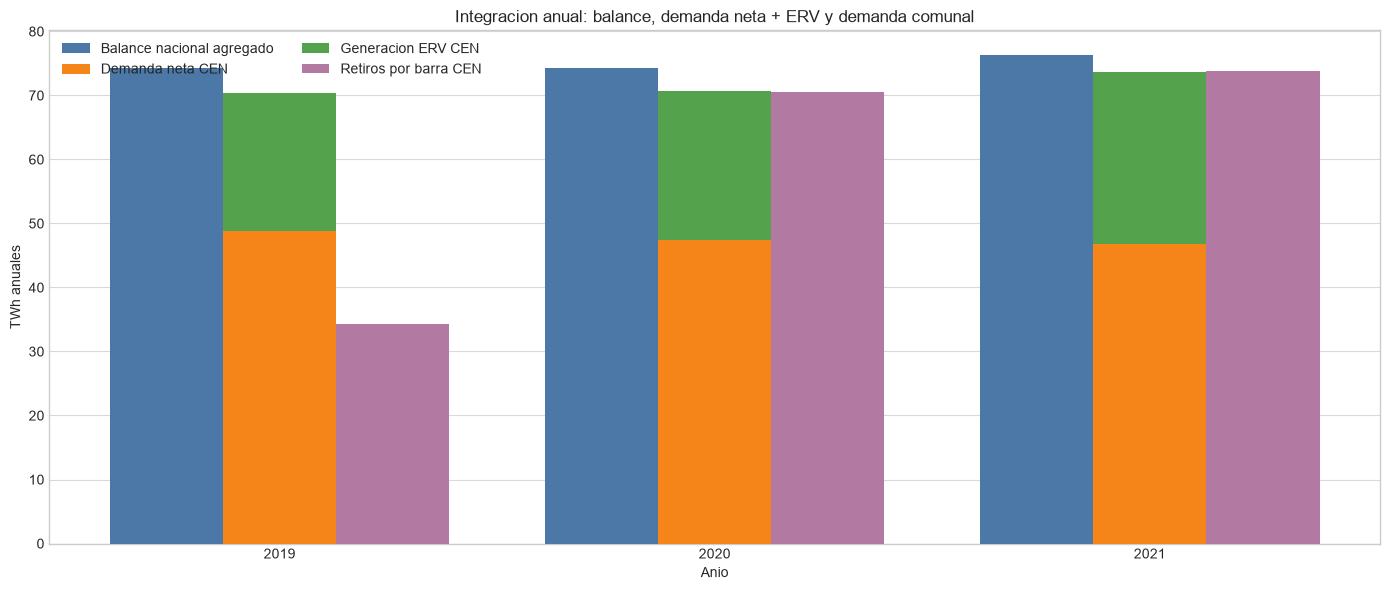

Grafico limitado a anios completos y comunes: [2019, 2020, 2021]
Anios comunes excluidos del grafico por cobertura incompleta o parcial: [2018, 2022, 2023]


,Estado CEN,Estado comunal,Horas faltantes CEN,Horas faltantes comunal
anio,,,,
2018,Completo,Parcial,0,"5,089.00"
2022,Completo,Incompleto,0,720.00
2023,Incompleto,Completo,96,0.00


In [12]:
print("[13/15] Graficando comparacion anual integrada...")

plot_anual = comparacion_anual.set_index("anio")
plot_anual_comun = plot_anual.dropna(
    subset=[
        "balance_nacional_anual_twh",
        "demanda_comunal_anual_twh",
        "demanda_neta_anual_twh",
        "gen_erv_anual_twh",
    ]
)
plot_anual_completo = plot_anual_comun[
    (plot_anual_comun["estado"] == "Completo")
    & (plot_anual_comun["estado_comunal"] == "Completo")
]

anios_excluidos_grafico = sorted(set(plot_anual_comun.index).difference(plot_anual_completo.index))

if plot_anual_completo.empty:
    print("No hay anios completos y comunes entre CEN, balance y demanda comunal para graficar.")
else:
    x = np.arange(len(plot_anual_completo.index))
    width = 0.26

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.85", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.bar(
        x - width,
        plot_anual_completo["balance_nacional_anual_twh"],
        width=width,
        label="Balance nacional agregado",
        color="#4C78A8",
        zorder=3,
    )
    ax.bar(
        x,
        plot_anual_completo["demanda_neta_anual_twh"],
        width=width,
        label="Demanda neta CEN",
        color="#F58518",
        zorder=3,
    )
    ax.bar(
        x,
        plot_anual_completo["gen_erv_anual_twh"],
        width=width,
        bottom=plot_anual_completo["demanda_neta_anual_twh"],
        label="Generacion ERV CEN",
        color="#54A24B",
        zorder=3,
    )
    ax.bar(
        x + width,
        plot_anual_completo["demanda_comunal_anual_twh"],
        width=width,
        label="Retiros por barra CEN",
        color="#B279A2",
        zorder=3,
    )

    ax.set_title("Integracion anual: balance, demanda neta + ERV y demanda comunal")
    ax.set_xlabel("Anio")
    ax.set_ylabel("TWh anuales")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_anual_completo.index.astype(str), rotation=0)
    ax.legend(ncol=2, loc="upper left")

    plt.tight_layout()
    plt.show()

    print(f"Grafico limitado a anios completos y comunes: {plot_anual_completo.index.tolist()}")

if anios_excluidos_grafico:
    print(f"Anios comunes excluidos del grafico por cobertura incompleta o parcial: {anios_excluidos_grafico}")
    display(
        plot_anual_comun.loc[
            anios_excluidos_grafico,
            ["estado", "estado_comunal", "horas_faltantes_calendario", "horas_faltantes_comunal"],
        ].rename(
            columns={
                "estado": "Estado CEN",
                "estado_comunal": "Estado comunal",
                "horas_faltantes_calendario": "Horas faltantes CEN",
                "horas_faltantes_comunal": "Horas faltantes comunal",
            }
        )
    )


[14/15] Graficando comparacion por horas coincidentes CEN/retiros...


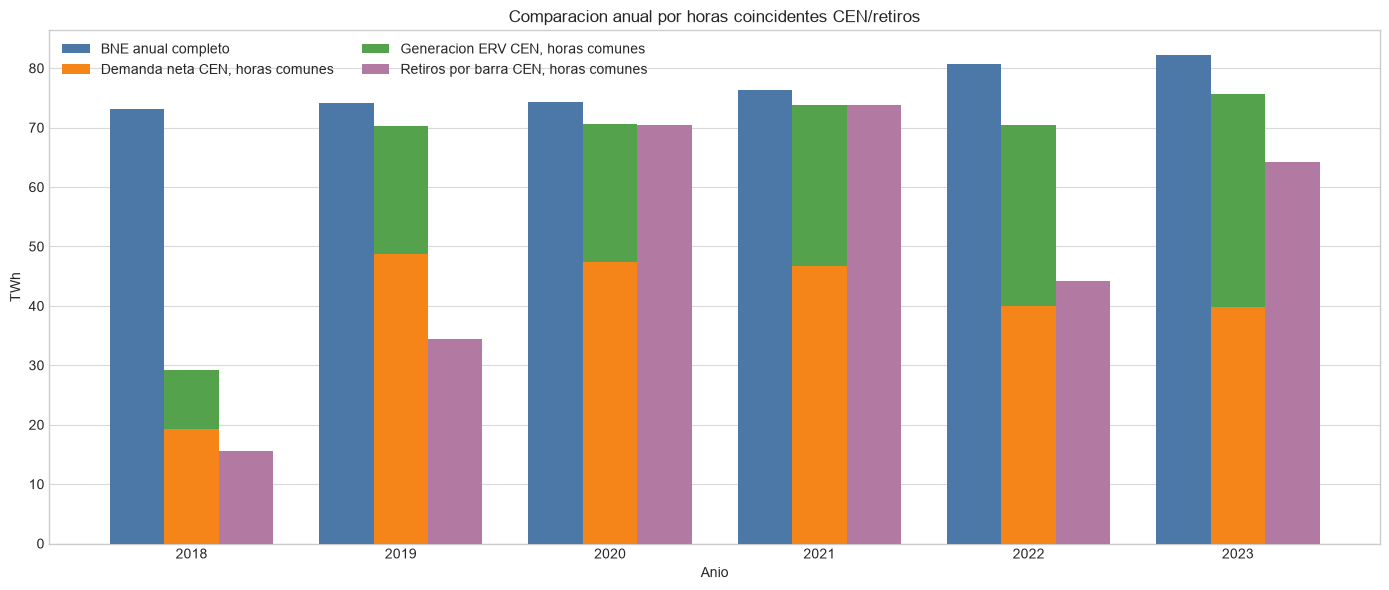

BNE se muestra como referencia anual completa; no esta filtrado por horas comunes.


In [13]:
print("[14/15] Graficando comparacion por horas coincidentes CEN/retiros...")

plot_horas_comunes = comparacion_horas_comunes_anual.set_index("anio")

if plot_horas_comunes.empty:
    print("No hay horas coincidentes entre CEN y retiros por barra para graficar.")
else:
    x = np.arange(len(plot_horas_comunes.index))
    width = 0.26

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="0.85", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.bar(x - width, plot_horas_comunes["balance_nacional_anual_twh"], width=width, label="BNE anual completo", color="#4C78A8", zorder=3)
    ax.bar(x, plot_horas_comunes["demanda_neta_comun_twh"], width=width, label="Demanda neta CEN, horas comunes", color="#F58518", zorder=3)
    ax.bar(x, plot_horas_comunes["gen_erv_comun_twh"], width=width, bottom=plot_horas_comunes["demanda_neta_comun_twh"], label="Generacion ERV CEN, horas comunes", color="#54A24B", zorder=3)
    ax.bar(x + width, plot_horas_comunes["retiros_barra_comun_twh"], width=width, label="Retiros por barra CEN, horas comunes", color="#B279A2", zorder=3)

    ax.set_title("Comparacion anual por horas coincidentes CEN/retiros")
    ax.set_xlabel("Anio")
    ax.set_ylabel("TWh")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_horas_comunes.index.astype(str), rotation=0)
    ax.legend(ncol=2, loc="upper left")

    plt.tight_layout()
    plt.show()

    print("BNE se muestra como referencia anual completa; no esta filtrado por horas comunes.")


In [14]:
print("[15/15] Interpretacion automatica")

anios_completos = comparacion_anual.loc[comparacion_anual["estado"] == "Completo", "anio"].tolist()
anios_no_completos = comparacion_anual.loc[
    comparacion_anual["estado"] != "Completo",
    ["anio", "estado", "horas_faltantes_calendario"],
]

max_gap_row = comparacion_anual.loc[comparacion_anual["diferencia_twh"].idxmax()]
min_gap_row = comparacion_anual.loc[comparacion_anual["diferencia_twh"].idxmin()]
comparacion_con_balance = comparacion_anual.dropna(subset=["balance_nacional_anual_twh"])
comparacion_con_comunal = comparacion_anual.dropna(subset=["demanda_comunal_anual_twh"])

print(f"Anios completos CEN: {anios_completos}")
if anios_no_completos.empty:
    print("No se detectaron anios CEN parciales o incompletos.")
else:
    print("Anios CEN parciales o incompletos detectados:")
    display(anios_no_completos.rename(columns={"anio": "Anio", "estado": "Estado", "horas_faltantes_calendario": "Horas faltantes calendario"}))

print(
    "Mayor brecha anual entre demanda neta CEN y demanda neta + ERV CEN: "
    f"{int(max_gap_row['anio'])} con {max_gap_row['diferencia_twh']:,.2f} TWh "
    f"({max_gap_row['diferencia_pct_sobre_demanda_neta']:,.2f}% de la demanda neta)."
)
print(
    "Menor brecha anual entre demanda neta CEN y demanda neta + ERV CEN: "
    f"{int(min_gap_row['anio'])} con {min_gap_row['diferencia_twh']:,.2f} TWh "
    f"({min_gap_row['diferencia_pct_sobre_demanda_neta']:,.2f}% de la demanda neta)."
)
print("La diferencia CEN anual coincide con la generacion ERV anual, porque demanda_mas_erv_mwh = demanda_neta_mwh + gen_erv_mwh.")

if comparacion_con_balance.empty:
    print("No hay anios comunes entre CEN y balance para interpretar la comparacion nacional agregada.")
else:
    max_balance_neta = comparacion_con_balance.loc[comparacion_con_balance["balance_vs_demanda_neta_twh"].abs().idxmax()]
    max_balance_mas_erv = comparacion_con_balance.loc[comparacion_con_balance["balance_vs_demanda_mas_erv_twh"].abs().idxmax()]
    print(
        "Mayor diferencia absoluta balance nacional vs demanda neta CEN: "
        f"{int(max_balance_neta['anio'])} con {max_balance_neta['balance_vs_demanda_neta_twh']:,.2f} TWh "
        f"({max_balance_neta['balance_vs_demanda_neta_pct']:,.2f}%)."
    )
    print(
        "Mayor diferencia absoluta balance nacional vs demanda neta + ERV CEN: "
        f"{int(max_balance_mas_erv['anio'])} con {max_balance_mas_erv['balance_vs_demanda_mas_erv_twh']:,.2f} TWh "
        f"({max_balance_mas_erv['balance_vs_demanda_mas_erv_pct']:,.2f}%)."
    )
    print("El balance regional-sectorial fue agregado desde GWh y convertido a TWh para visualizacion mediante GWh / 1000.")

if comparacion_con_comunal.empty:
    print("No hay anios con retiros por barra disponibles para interpretar la comparacion nacional agregada.")
else:
    max_comunal_cen = comparacion_con_comunal.loc[comparacion_con_comunal["comunal_vs_demanda_mas_erv_twh"].abs().idxmax()]
    max_comunal_balance = comparacion_con_comunal.dropna(subset=["comunal_vs_balance_twh"])
    print(
        "Mayor diferencia absoluta retiros por barra CEN vs demanda neta + ERV CEN: "
        f"{int(max_comunal_cen['anio'])} con {max_comunal_cen['comunal_vs_demanda_mas_erv_twh']:,.2f} TWh."
    )
    if not max_comunal_balance.empty:
        max_comunal_balance_row = max_comunal_balance.loc[max_comunal_balance["comunal_vs_balance_twh"].abs().idxmax()]
        print(
            "Mayor diferencia absoluta retiros por barra CEN vs balance nacional: "
            f"{int(max_comunal_balance_row['anio'])} con {max_comunal_balance_row['comunal_vs_balance_twh']:,.2f} TWh."
        )
    print("Los retiros por barra conservan valores negativos en la suma anual y los reportan como diagnostico por anio.")

if 'comparacion_horas_comunes_anual' in globals() and not comparacion_horas_comunes_anual.empty:
    max_horas_comunes = comparacion_horas_comunes_anual.loc[
        comparacion_horas_comunes_anual["retiros_vs_demanda_mas_erv_comun_twh"].abs().idxmax()
    ]
    print(
        "En la comparacion por horas coincidentes, la mayor diferencia absoluta retiros vs demanda neta + ERV ocurre en "
        f"{int(max_horas_comunes['anio'])}: {max_horas_comunes['retiros_vs_demanda_mas_erv_comun_twh']:,.2f} TWh "
        f"sobre {int(max_horas_comunes['horas_coincidentes'])} horas coincidentes."
    )
    print("En esa comparacion, BNE se muestra como referencia anual completa y no se filtra por horas comunes.")


[15/15] Interpretacion automatica
Anios completos CEN: [2017, 2018, 2019, 2020, 2021, 2022, 2024, 2025]
Anios CEN parciales o incompletos detectados:


,Anio,Estado,Horas faltantes calendario
6,2023,Incompleto,96
9,2026,Parcial,5448


Mayor brecha anual entre demanda neta CEN y demanda neta + ERV CEN: 2025 con 41.99 TWh (111.04% de la demanda neta).
Menor brecha anual entre demanda neta CEN y demanda neta + ERV CEN: 2026 con 17.09 TWh (123.93% de la demanda neta).
La diferencia CEN anual coincide con la generacion ERV anual, porque demanda_mas_erv_mwh = demanda_neta_mwh + gen_erv_mwh.
Mayor diferencia absoluta balance nacional vs demanda neta CEN: 2024 con 44.02 TWh (115.47%).
Mayor diferencia absoluta balance nacional vs demanda neta + ERV CEN: 2023 con 6.50 TWh (8.58%).
El balance regional-sectorial fue agregado desde GWh y convertido a TWh para visualizacion mediante GWh / 1000.
Mayor diferencia absoluta retiros por barra CEN vs demanda neta + ERV CEN: 2018 con -54.60 TWh.
Mayor diferencia absoluta retiros por barra CEN vs balance nacional: 2018 con -57.63 TWh.
Los retiros por barra conservan valores negativos en la suma anual y los reportan como diagnostico por anio.
En la comparacion por horas coincidentes, la 